## Week 8 – Visualization & Market Insights

This section uses charts to understand housing prices, market trends, and differences across locations. The goal is to clearly show patterns in the data using simple visuals.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (use filtered for cleaner visuals)""
sold = pd.read_csv("output/sold_filtered.csv")

# Convert date + create time feature
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'], errors='coerce')
sold['year_month'] = sold['CloseDate'].dt.to_period('M')

/var/folders/j3/fcm5lwl97232mcc0j6k8vwnr0000gn/T/ipykernel_16519/1426539337.py:5: DtypeWarning: Columns (0,1,4,9,64,78,79,80,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("output/sold_filtered.csv")


In [2]:
import os
print(os.listdir())

['week8_visualizations.ipynb', 'sold_aggregation.py', '.DS_Store', 'crmls_sold.py', 'week6', 'week1', 'week0', 'week7', 'output', 'combined_movies_data_standardized.csv', 'README.md', '.gitignore', 'week2', 'week5', '.venv', 'listings_aggregation.py', 'week4', '.git', 'eda_test.ipynb', 'venv311', 'crmls_listed.py', 'raw', 'eda_analysis.ipynb']


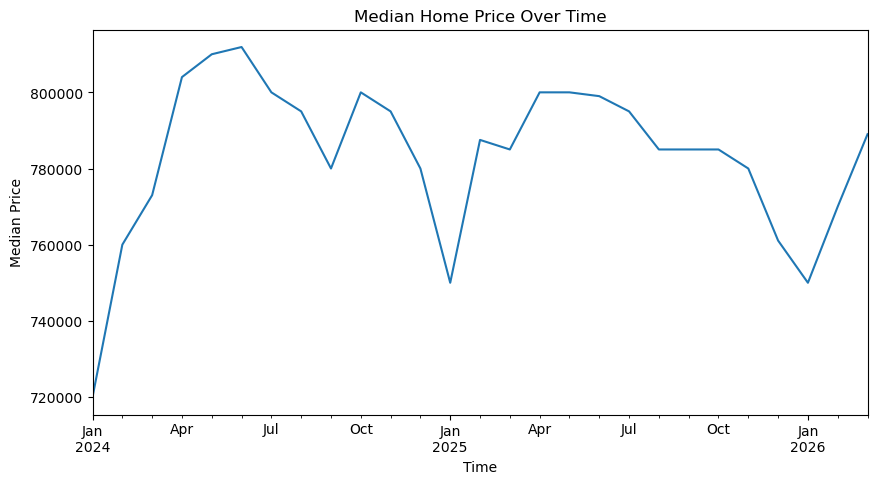

In [4]:
trend = sold.groupby('year_month')['ClosePrice'].median()

trend.plot(figsize=(10,5))

plt.title("Median Home Price Over Time")
plt.xlabel("Time")
plt.ylabel("Median Price")

plt.show()

Home prices change over time. This chart shows the general trend of the housing market and helps us see if prices are increasing or decreasing.

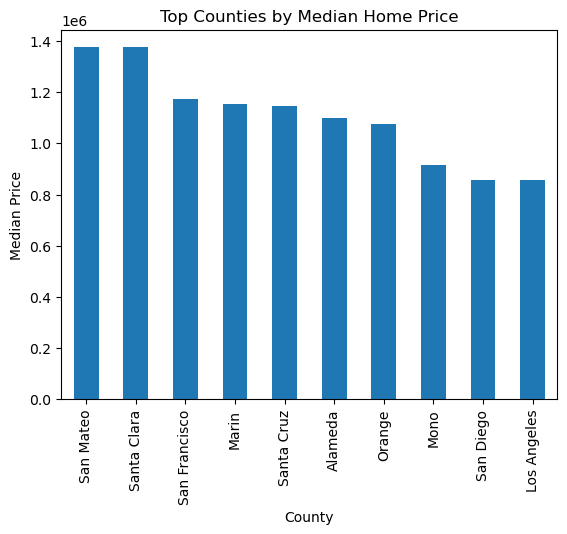

In [5]:
county = sold.groupby('CountyOrParish')['ClosePrice'].median() \
            .sort_values(ascending=False).head(10)

county.plot(kind='bar')

plt.title("Top Counties by Median Home Price")
plt.xlabel("County")
plt.ylabel("Median Price")

plt.show()


Different counties have different price levels. This chart compares median home prices across counties to show which areas are more expensive.

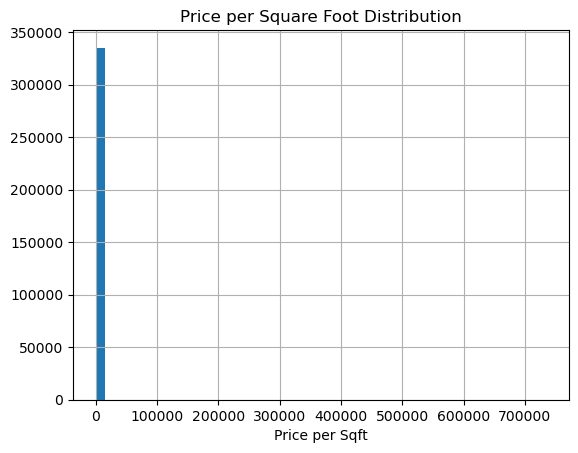

In [6]:

sold['price_per_sqft'].hist(bins=50)

plt.title("Price per Square Foot Distribution")
plt.xlabel("Price per Sqft")

plt.show()


This chart shows how much buyers pay per square foot. It helps compare property value across homes of different sizes.

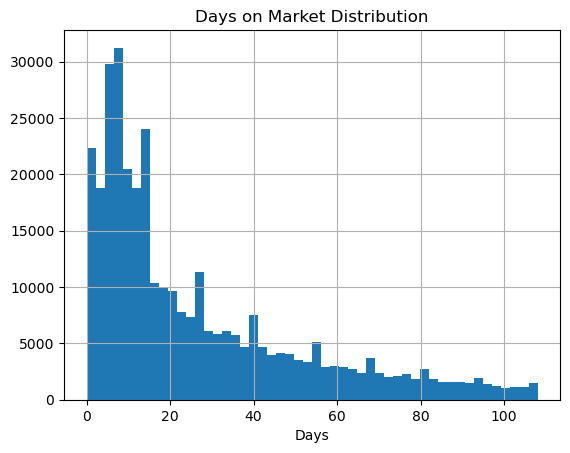

In [7]:
sold['DaysOnMarket'].hist(bins=50)

plt.title("Days on Market Distribution")
plt.xlabel("Days")

plt.show()

This chart shows how long homes stay on the market before selling. Shorter times usually mean higher demand.

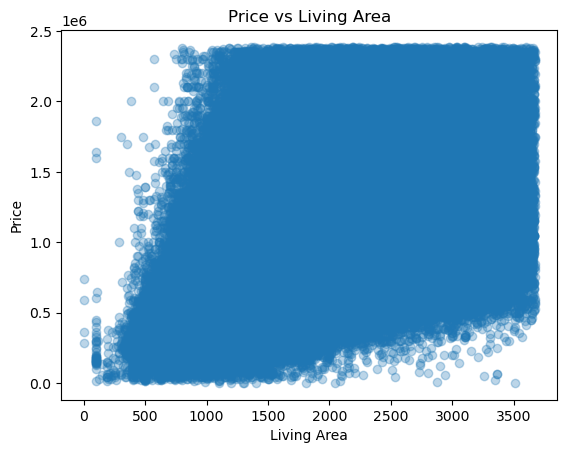

In [8]:
plt.scatter(sold['LivingArea'], sold['ClosePrice'], alpha=0.3)

plt.title("Price vs Living Area")
plt.xlabel("Living Area")
plt.ylabel("Price")

plt.show()

This chart shows the relationship between home size and price. Larger homes generally cost more, but the spread shows that other factors also affect price.

/var/folders/j3/fcm5lwl97232mcc0j6k8vwnr0000gn/T/ipykernel_16519/444884761.py:1: DtypeWarning: Columns (0,1,4,9,64,78,79,80,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  original = pd.read_csv("output/sold_features.csv")


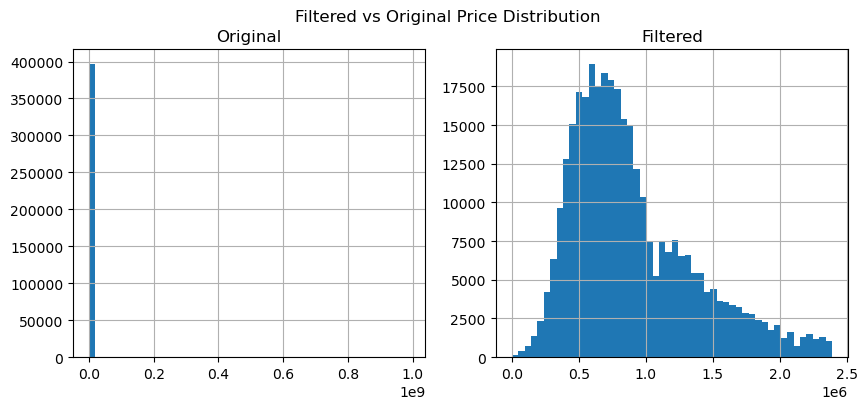

In [11]:
original = pd.read_csv("output/sold_features.csv")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
original['ClosePrice'].hist(bins=50)
plt.title("Original")

plt.subplot(1,2,2)
sold['ClosePrice'].hist(bins=50)
plt.title("Filtered")

plt.suptitle("Filtered vs Original Price Distribution")

plt.show()

After removing extreme values, the data becomes easier to understand. This shows how outliers can affect the overall picture.